# 03 Bin Exploration

Notebook canónico. Los datos se leen de `data/processed/` y los productos derivados se guardan en `results/`.


In [1]:
# Canonical notebook setup
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.microbiome_analysis.paths import DATASETS_DIR, analysis_output_dirs

ANALYSIS = '03_bin_exploration'
OUTPUTS = analysis_output_dirs(ANALYSIS)
# Guardar figuras nuevas en OUTPUTS['figures'] y tablas en OUTPUTS['tables'].


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast

In [3]:
classification = pd.read_csv(DATASETS_DIR / 'gtdbtk_classification.tsv', sep='\t')

In [4]:
classification

,user_genome,classification,fastani_reference,fastani_reference_radius,fastani_taxonomy,fastani_ani,fastani_af,closest_placement_reference,closest_placement_radius,closest_placement_taxonomy,closest_placement_ani,closest_placement_af,pplacer_taxonomy,classification_method,note,"other_related_references(genome_id,species_name,radius,ANI,AF)",msa_percent,translation_table,red_value,warnings
0,36703_3#1.001,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,GCA_000020605.1,95.0,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,97.56,0.77,GCA_000020605.1,95.0,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,97.56,0.77,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,taxonomic classification defined by topology a...,topological placement and ANI have congruent s...,"GCA_900317585.1, s__Agathobacter sp900317585, ...",88.90,11.0,NaN,NaN
1,36703_3#1.002,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,GCA_025149785.1,95.0,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,98.07,0.78,GCA_025149785.1,95.0,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,98.07,0.78,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,taxonomic classification defined by topology a...,topological placement and ANI have congruent s...,"GCF_013300725.1, s__Bariatricus comes_A, 95.0,...",84.53,11.0,NaN,NaN
2,36703_3#1.003,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,GCF_003324185.1,95.0,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,96.87,0.92,GCF_003324185.1,95.0,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,96.87,0.92,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,taxonomic classification defined by topology a...,topological placement and ANI have congruent s...,"GCF_023347235.1, s__Faecalibacterium prausnitz...",85.72,11.0,NaN,NaN
3,36703_3#1.004,Unclassified Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Insufficient number of amino acids in MSA (8.3%)
4,36703_3#1.005,Unclassified Bacteria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Insufficient number of amino acids in MSA (9.5%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7407,37082_3#9.037,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Cl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Cl...,taxonomic classification defined by topology a...,classification based on placement in class-lev...,"GCF_017873235.1, s__Clostridium moniliforme, 9...",17.58,11.0,0.945389,Genome not assigned to closest species as it f...
7408,37082_3#9.038,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Cl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Cl...,ANI,classification based on placement in class-lev...,"GCF_014287815.1, s__Clostridium sp001916075, 9...",19.07,11.0,0.940227,Genome has more than 12.5% of markers with mul...
7409,37082_3#9.039,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,GCA_022010055.1,95.0,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,96.97,0.51,GCA_022010055.1,95.0,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,96.97,0.51,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,taxonomic classification defined by topology a...,topological placement and ANI have congruent s...,"GCA_900317625.1, s__Treponema_D sp900317625, 9...",27.59,11.0,NaN,NaN
7410,37082_3#9.040,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Cl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Cl...,taxonomic classification defined by topology a...,classification based on placement in class-lev...,"GCF_014287815.1, s__Clostridium sp001916075, 9...",19.98,11.0,0.978209,Genome not assigned to closest species as it f...


In [5]:
data = pd.read_csv(DATASETS_DIR / 'bin_quality_final.tsv', sep = '\t', header = None)

In [6]:
metadata = pd.read_csv(DATASETS_DIR / 'latinbiota_sample_metadata.csv')

In [7]:
data.columns  = ['ID BIN', 'INFO']

In [8]:
bins_quality = []
for item in list(data['INFO']):
    # Convert string to dictionary
    data_dict = ast.literal_eval(item)

    # Print the dictionary
    bins_quality.append(data_dict)
    # aux = item.strip().replace('{', '').replace('}', '').replace("'", '').replace(' ', '').split(',')
    # print(aux)

In [9]:
df_bins = pd.DataFrame(bins_quality)

In [10]:
df_bins.index = data['ID BIN']

In [11]:
df_bins['Completeness'].dtype

dtype('float64')

In [12]:
aux_gbm_quality = df_bins[(df_bins['Completeness'] >= 50) & (df_bins['Contamination'] <= 10)]

In [13]:
aux_gbm_quality.to_csv(OUTPUTS['tables'] / 'bin_gbm_quality.csv')

In [14]:
good_quality = df_bins[(df_bins['Completeness'] >= 95) & (df_bins['Contamination'] <= 5)]

In [15]:
rural = list(metadata[metadata['Lifestyle'] == 'Urban']['Lane'])

In [16]:
good_quality

,marker lineage,# genomes,# markers,# marker sets,0,1,2,3,4,5+,...,Mean contig length,Coding density,Translation table,# predicted genes,GCN0,GCN1,GCN2,GCN3,GCN4,GCN5+
ID BIN,,,,,,,,,,,,,,,,,,,,,
36703_3#1.003,o__Clostridiales,172,261,147,3,240,18,0,0,0,...,16934.880282,0.875015,11,2213,"[PF00177, PF00237, PF01197]","[PF03461, PF07136, PF10396, PF00572, PF00154, ...","[PF00238, PF00861, PF00573, PF01649, PF00281, ...",[],[],[]
36703_3#1.007,f__Lachnospiraceae,57,420,207,24,392,4,0,0,0,...,20797.027972,0.905294,11,2827,"[PF10396, PF12631, PF02677, PF13603, PF03255, ...","[PF03461, PF07136, PF00572, PF00154, PF00164, ...","[TIGR00042, TIGR00499, PF00215, PF00140]",[],[],[]
36703_3#1.001,f__Lachnospiraceae,57,420,207,3,410,7,0,0,0,...,12971.685921,0.876374,11,3582,"[PF13603, PF00208, PF02812]","[PF03461, PF07136, PF10396, PF00572, PF00154, ...","[PF03838, PF02768, PF00464, PF02767, PF04760, ...",[],[],[]
36703_3#10.006,o__Clostridiales,155,278,158,9,268,1,0,0,0,...,26434.675214,0.881927,11,2771,"[TIGR00185, TIGR01069, PF03652, PF13603, PF083...","[PF02670, PF06969, PF09285, TIGR01133, PF00572...",[PF01725],[],[],[]
36703_3#10.008,p__Actinobacteria,31,211,124,0,210,1,0,0,0,...,36200.116667,0.874307,11,1883,[],"[PF09285, PF01649, PF04560, PF09269, PF01795, ...",[TIGR01455],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#7.001,o__Clostridiales,172,263,149,3,260,0,0,0,0,...,20849.317757,0.897121,11,2105,"[PF06969, PF13603, PF07479]","[PF00154, PF02132, TIGR03994, PF04263, TIGR002...",[],[],[],[]
37082_3#7.016,o__Clostridiales,304,250,143,6,240,4,0,0,0,...,13033.092715,0.859784,11,1797,"[TIGR01378, PF13603, PF05191, PF07479, PF02603...","[TIGR00182, PF00154, PF02132, TIGR03994, PF028...","[PF01406, PF00035, PF01725, PF01702]",[],[],[]
37082_3#8.015,f__Spirochaetaceae,33,249,143,43,197,9,0,0,0,...,8397.566176,0.903783,11,2079,"[PF00203, PF01000, PF00831, PF00237, PF01193, ...","[PF00707, PF02938, PF01624, PF02768, PF02911, ...","[PF01653, TIGR02191, PF00318, PF01165, TIGR001...",[],[],[]


In [17]:
good_quality['Sample Name'] = good_quality.index.str[:-4]

C:\Users\rafap\AppData\Local\Temp\ipykernel_2512\3960523967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_quality['Sample Name'] = good_quality.index.str[:-4]


In [18]:
good_quality_rural = good_quality[~good_quality['Sample Name'].isin(rural)]

In [19]:
index_good = list(good_quality_rural.index)

In [20]:
classification = pd.read_csv(DATASETS_DIR / 'gtdbtk_classification.tsv', sep='\t')

In [21]:
c = classification[classification['user_genome'].isin(index_good)][['user_genome', 'classification']]

In [22]:
classified_species = c[c['classification'].str.contains('s__')].copy()

In [23]:
classified_species['Species'] = [x.split(';')[-1].replace('s__', '') for x in list(classified_species['classification'])]

In [24]:
classified_species = classified_species[classified_species['Species'] != '']

In [25]:
classified_species

,user_genome,classification,Species
68,36703_3#12.001,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B
77,36703_3#12.010,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Eubacterium_R sp000436835
78,36703_3#12.011,d__Bacteria;p__Bacillota_C;c__Negativicutes;o_...,Dialister sp000434475
121,36703_3#13.006,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E sp934476515
125,36703_3#13.010,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B
...,...,...,...
7214,37082_3#7.001,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Eubacterium_R coprostanoligenes
7228,37082_3#7.016,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Ch...,PeH17 sp000435055
7310,37082_3#8.015,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,Treponema_D sp900541945
7372,37082_3#9.002,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Bifidobacterium pseudocatenulatum


In [26]:
classified_species['Species'].unique()

array(['Ruminococcus_E bromii_B', 'Eubacterium_R sp000436835',
       'Dialister sp000434475', 'Ruminococcus_E sp934476515',
       'Limosilactobacillus mucosae', 'Agathobacter rectalis',
       'Bifidobacterium adolescentis', 'Gemmiger sp900539695',
       'Slackia_A isoflavoniconvertens', 'Dialister invisus',
       'Bifidobacterium pseudocatenulatum', 'Enterococcus_B faecium',
       'CAG-217 sp000436335', 'Pseudoruminococcus massiliensis',
       'PeH17 sp000435055', 'Phil1 sp001940855', 'Bulleidia sp900539965',
       'Catenibacterium mitsuokai', 'Bifidobacterium angulatum',
       'Eubacterium_R sp000433975', 'Enterococcus_B hirae',
       'Catenibacterium sp900540685', 'Blautia_A wexlerae',
       'CAG-882 sp003486385', 'Fusicatenibacter saccharivorans',
       'Streptococcus lutetiensis', 'Sarcina perfringens',
       'Escherichia coli', 'Campylobacter_D sp900539255',
       'Coprococcus eutactus_A', 'Eubacterium_R sp000434995',
       'Fimenecus sp000432435', 'UBA11524 sp00043

In [27]:
rural_sp = ['Agathobacter rectalis', 'Faecalibacterium prausnitzii',
       'Agathobacter faecis', 'Fusicatenibacter saccharivorans',
       'Bifidobacterium longum', 'CAG-41 sp900066215',
       'Ruminococcus_E bromii_B', 'Prevotella sp900313215',
       'Faecalibacterium prausnitzii_D', 'Lachnospira sp900316325',
       'CAG-217 sp000436335', 'Phocaeicola vulgatus',
       'Fimenecus sp000432435', 'Veillonella parvula_A',
       'Mediterraneibacter torques', 'Bifidobacterium bifidum',
       'Streptococcus sp934196125', 'UBA3375 sp900551955',
       'Ruminococcus_E sp003526955', 'UBA11524 sp000437595',
       'Ruminococcus_D bicirculans', 'CAG-177 sp003514385',
       'Escherichia coli', 'Lachnospira rogosae',
       'Ruminococcus_C sp000433635', 'RUG115 sp900066395',
       'Phascolarctobacterium_A succinatutens',
       'Butyrivibrio_A sp000431815', 'Acetatifactor intestinalis',
       'Alistipes putredinis', 'Faecalibacterium longum',
       'Lachnospira eligens_A', 'Alistipes onderdonkii',
       'Akkermansia muciniphila', 'CAZU01 sp000432275',
       'Roseburia inulinivorans', 'Eubacterium_F sp003491505',
       'Butyrivibrio_A crossotus', 'CAG-873 sp001701165',
       'CAG-177 sp000431775', 'CAG-349 sp003539515',
       'Bacteroides stercoris', 'Wujia chipingensis',
       'Mediterraneibacter lactaris', 'CAG-882 sp003486385',
       'Phascolarctobacterium faecium', 'Bacteroides gallinarum',
       'Faecalibacterium sp900539885', 'Paraprevotella clara',
       'Bifidobacterium adolescentis', 'UBA1417 sp003531055',
       'Eubacterium_R sp000436835', 'Bacteroides uniformis',
       'PeH17 sp000435055', 'Prevotella copri_B',
       'Ruminococcus sp002438605', 'Eubacterium_R sp900539775',
       'Dialister sp000434475', 'Prevotella sp015074785',
       'Pseudoruminococcus massiliensis', 'Eubacterium_R sp900539325',
       'Fusobacterium_A sp900555845', 'Akkermansia sp001580195',
       'Gemmiger qucibialis', 'Coprococcus eutactus', 'Prevotella copri',
       'Phocaeicola plebeius_A', 'Ruminiclostridium_E siraeum',
       'Roseburia intestinalis', 'Phocaeicola dorei',
       'Megamonas funiformis', 'Bariatricus comes',
       'Lachnospira sp003451515', 'Eubacterium_R sp000434995',
       'Catenibacterium sp000437715', 'Barnesiella intestinihominis',
       'Coprococcus eutactus_A', 'Dialister sp900541605',
       'CAG-353 sp900066885', 'Dialister hominis', 'Prevotella copri_C',
       'Alloprevotella sp900543155', 'Parabacteroides distasonis',
       'Collinsella sp905216145', 'SFEL01 sp004557245',
       'Enterocloster porci', 'CAG-177 sp003538135',
       'Ruminococcus_C sp900545285', 'Faecalibacterium duncaniae',
       'Ruminococcus_E sp934476515', 'Holdemanella porci_A',
       'Blautia_A wexlerae', 'Faecalibacillus intestinalis',
       'Faecalibacillus faecis', 'Ruminococcus_E bromii',
       'Collinsella sp905197585', 'CAG-488 sp000434915']

In [28]:
urban_sp = ['Ruminococcus_E bromii_B', 'Eubacterium_R sp000436835',
       'Dialister sp000434475', 'Ruminococcus_E sp934476515',
       'Limosilactobacillus mucosae', 'Agathobacter rectalis',
       'Bifidobacterium adolescentis', 'Gemmiger sp900539695',
       'Slackia_A isoflavoniconvertens', 'Dialister invisus',
       'Bifidobacterium pseudocatenulatum', 'Enterococcus_B faecium',
       'CAG-217 sp000436335', 'Pseudoruminococcus massiliensis',
       'PeH17 sp000435055', 'Phil1 sp001940855', 'Bulleidia sp900539965',
       'Catenibacterium mitsuokai', 'Bifidobacterium angulatum',
       'Eubacterium_R sp000433975', 'Enterococcus_B hirae',
       'Catenibacterium sp900540685', 'Blautia_A wexlerae',
       'CAG-882 sp003486385', 'Fusicatenibacter saccharivorans',
       'Streptococcus lutetiensis', 'Sarcina perfringens',
       'Escherichia coli', 'Campylobacter_D sp900539255',
       'Coprococcus eutactus_A', 'Eubacterium_R sp000434995',
       'Fimenecus sp000432435', 'UBA11524 sp000437595',
       'Ligilactobacillus ruminis', 'Clostridium sp900540255',
       'Ruminococcus_E sp003438075', 'Ruminococcus_E sp003526955',
       'CAG-177 sp003514385', 'Sodaliphilus sp004557565',
       'UBA3375 sp900551955', 'Eubacterium_R sp900542875',
       'Treponema_D succinifaciens', 'Faecalibacterium sp900539945',
       'Blautia_A sp900066355', 'CAG-791 sp000431495',
       'CAG-303 sp900539455', 'Catenibacterium sp000437715',
       'CAG-488 sp000434055', 'Faecalibacillus intestinalis',
       'Clostridium sp001916075', 'Bifidobacterium dentium',
       'Akkermansia muciniphila', 'Treponema_D sp900541945',
       'Lentihominibacter faecis', 'Streptococcus sp934196125',
       'Bacteroides fragilis_A', 'CAG-103 sp900543625',
       'Mediterraneibacter torques', 'Parolsenella massiliensis',
       'Blautia_A massiliensis', 'Ruminococcus_E bromii',
       'Faecalibacterium sp934503275', 'CAG-95 sp900553305',
       'ER4 sp000765235', 'Alloprevotella sp900543155',
       'Lachnospira sp000436535', 'Streptococcus sp000187445',
       'Bifidobacterium longum', 'Bifidobacterium bifidum',
       'Faecalibacterium prausnitzii_E', 'Fimenecus sp004556705',
       'Acetatifactor intestinalis', 'Gemmiger qucibialis',
       'CAG-510 sp000434615', 'Ruminococcus_C sp000433635',
       'Bulleidia sp934754415', 'Treponema_D peruense',
       'Ruminococcus_E sp900543095', 'Weissella cibaria',
       'Phoenicibacter congonensis', 'Ruminiclostridium_E sp934490165',
       'Eubacterium_R sp003526845', 'Cetobacterium_A sp934085975',
       'Acetatifactor sp900066565', 'Holdemanella sp900556915',
       'Acetatifactor sp003447295', 'Paratractidigestivibacter faecalis',
       'CAG-877 sp934168205', 'Sarcina ventriculi',
       'Klebsiella pneumoniae', 'Limisoma sp000437795',
       'Butyrivibrio_A crossotus', 'Bacteroides fragilis',
       'Faecalibacterium prausnitzii_J',
       'Eubacterium_R coprostanoligenes']

In [29]:
selected_species = sorted(set(rural_sp + urban_sp))

In [30]:
len(selected_species)

159

In [31]:
otus = pd.read_csv(DATASETS_DIR / 'taxonomy_table_otus.csv', index_col = 0)

In [32]:
otus.columns

Index(['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species'], dtype='object')

In [33]:
otus['SpeciesFull'] = otus['Genus'] + ' ' + otus['Species']

In [34]:
matched = otus[otus['SpeciesFull'].isin(selected_species)]

In [35]:
matched.to_csv(OUTPUTS['tables'] / 'bin_metadata_matches.csv')

In [36]:
otus['Genus'].unique()

array(['Wujia', 'Mediterraneibacter', 'Roseburia', ..., 'Canoevirus',
       'Dianthovirus', 'Madisduvirus'], dtype=object)

In [37]:
otus[otus['Family'].str.contains('Lachnospiraceae', na=False)].tail(50)

,Kingdom,Phylum,Class,Order,Family,Genus,Species,SpeciesFull
33035,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Blautia,producta,Blautia producta
1912897,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Blautia,argi,Blautia argi
1322,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Blautia,hansenii,Blautia hansenii
1796616,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Blautia,pseudococcoides,Blautia pseudococcoides
2779518,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Blautia,liquoris,Blautia liquoris
1737424,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Blautia,massiliensis,Blautia massiliensis
410072,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Coprococcus,comes,Coprococcus comes
116085,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Coprococcus,catus,Coprococcus catus
751585,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Coprococcus,sp. ART55/1,Coprococcus sp. ART55/1
33043,Bacteria,Bacillota,Clostridia,Eubacteriales,Lachnospiraceae,Coprococcus,eutactus,Coprococcus eutactus


In [38]:
species_counts = classified_species['Species'].value_counts()

In [39]:
species_counts

Species
Ruminococcus_E bromii_B            25
Escherichia coli                   16
UBA3375 sp900551955                10
Ligilactobacillus ruminis           9
Ruminococcus_E sp003526955          9
                                   ..
Limisoma sp000437795                1
Butyrivibrio_A crossotus            1
Bacteroides fragilis                1
Faecalibacterium prausnitzii_J      1
Eubacterium_R coprostanoligenes     1
Name: count, Length: 95, dtype: int64

In [40]:
mayores_species =species_counts[species_counts > 5]

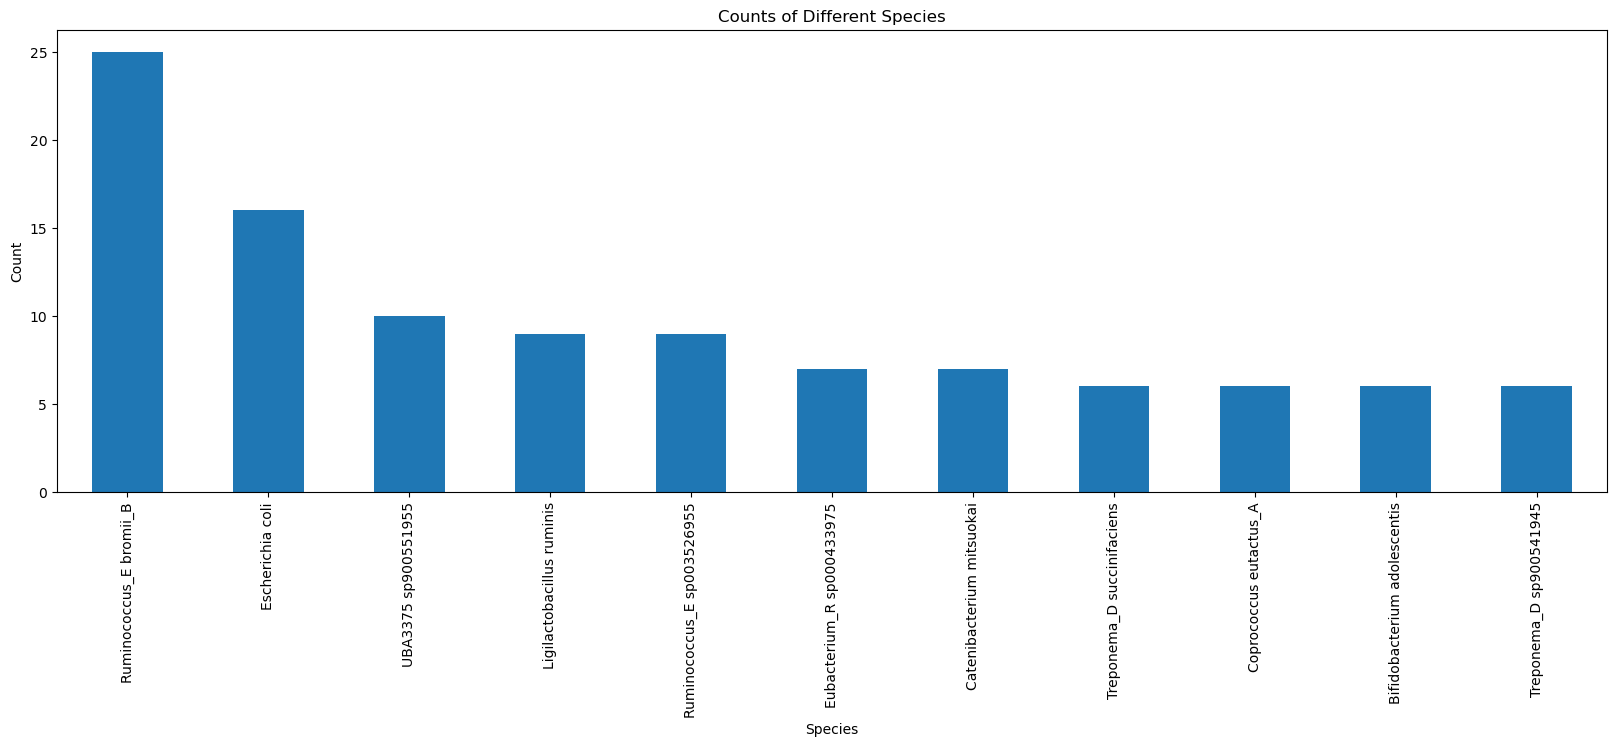

In [41]:
mayores_species.plot(kind='bar', figsize=(20, 6))

# Add labels and title
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Counts of Different Species')

# Show the plot
plt.show()

In [42]:
#Count plot rural/urbano
rural = ['37082_3#9','37082_3#8','37082_3#7','37082_3#6','37082_3#5','37082_3#4','37082_3#32','37082_3#31','37082_3#30','37082_3#3','37082_3#29','37082_3#28','37082_3#27','37082_3#26','37082_3#25','37082_3#24','37082_3#23','37082_3#22','37082_3#21','37082_3#20','37082_3#2','37082_3#19','37082_3#17','37082_3#16','37082_3#15','37082_3#14','37082_3#13','37082_3#12','37082_3#11','37082_3#10','37082_3#1','37082_2#32','37082_2#31','37082_2#30','37082_2#29','37082_2#28','37082_2#27','37082_2#26','37082_2#25','37082_2#24','37082_2#23','37082_2#22','37082_2#21','37082_2#20','37082_2#19','37082_2#18','37082_2#17','37082_2#16','37035_7#9','37035_7#8','37035_7#7','37035_7#6','37035_7#5','37035_7#4','37035_7#3','37035_7#25','37035_7#24','37035_7#23','37035_7#22','37035_7#21','37035_7#20','37035_7#2','37035_7#19','37035_7#18','37035_7#17','37035_7#16','37035_7#15','37035_7#14','37035_7#13','37035_7#12','37035_7#11','37035_7#10','37035_7#1','37035_1#9','37035_1#8','37035_1#7','37035_1#6','37035_1#5','37035_1#4','37035_1#3','37035_1#27','37035_1#26','37035_1#25','37035_1#24','37035_1#23','37035_1#22','37035_1#21','37035_1#20','37035_1#2','37035_1#18','37035_1#17','37035_1#16','37035_1#15','37035_1#14','37035_1#13','37035_1#12','37035_1#11','37035_1#10','37035_1#1','36703_3#32','36703_3#31','36703_3#30','36703_3#29','36703_3#28','36703_3#27','36703_3#26','36703_3#25','36703_3#24','36703_3#23','36703_3#22','36703_3#21','36703_3#20','36703_3#19','36703_3#18','36703_3#17','36703_3#16','36703_3#15','36703_3#14','36703_3#13','36703_3#12']


In [43]:
classified_species

,user_genome,classification,Species
68,36703_3#12.001,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B
77,36703_3#12.010,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Eubacterium_R sp000436835
78,36703_3#12.011,d__Bacteria;p__Bacillota_C;c__Negativicutes;o_...,Dialister sp000434475
121,36703_3#13.006,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E sp934476515
125,36703_3#13.010,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B
...,...,...,...
7214,37082_3#7.001,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Eubacterium_R coprostanoligenes
7228,37082_3#7.016,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Ch...,PeH17 sp000435055
7310,37082_3#8.015,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,Treponema_D sp900541945
7372,37082_3#9.002,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Bifidobacterium pseudocatenulatum


In [44]:
good_quality

,marker lineage,# genomes,# markers,# marker sets,0,1,2,3,4,5+,...,Coding density,Translation table,# predicted genes,GCN0,GCN1,GCN2,GCN3,GCN4,GCN5+,Sample Name
ID BIN,,,,,,,,,,,,,,,,,,,,,
36703_3#1.003,o__Clostridiales,172,261,147,3,240,18,0,0,0,...,0.875015,11,2213,"[PF00177, PF00237, PF01197]","[PF03461, PF07136, PF10396, PF00572, PF00154, ...","[PF00238, PF00861, PF00573, PF01649, PF00281, ...",[],[],[],36703_3#1
36703_3#1.007,f__Lachnospiraceae,57,420,207,24,392,4,0,0,0,...,0.905294,11,2827,"[PF10396, PF12631, PF02677, PF13603, PF03255, ...","[PF03461, PF07136, PF00572, PF00154, PF00164, ...","[TIGR00042, TIGR00499, PF00215, PF00140]",[],[],[],36703_3#1
36703_3#1.001,f__Lachnospiraceae,57,420,207,3,410,7,0,0,0,...,0.876374,11,3582,"[PF13603, PF00208, PF02812]","[PF03461, PF07136, PF10396, PF00572, PF00154, ...","[PF03838, PF02768, PF00464, PF02767, PF04760, ...",[],[],[],36703_3#1
36703_3#10.006,o__Clostridiales,155,278,158,9,268,1,0,0,0,...,0.881927,11,2771,"[TIGR00185, TIGR01069, PF03652, PF13603, PF083...","[PF02670, PF06969, PF09285, TIGR01133, PF00572...",[PF01725],[],[],[],36703_3#10
36703_3#10.008,p__Actinobacteria,31,211,124,0,210,1,0,0,0,...,0.874307,11,1883,[],"[PF09285, PF01649, PF04560, PF09269, PF01795, ...",[TIGR01455],[],[],[],36703_3#10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37082_3#7.001,o__Clostridiales,172,263,149,3,260,0,0,0,0,...,0.897121,11,2105,"[PF06969, PF13603, PF07479]","[PF00154, PF02132, TIGR03994, PF04263, TIGR002...",[],[],[],[],37082_3#7
37082_3#7.016,o__Clostridiales,304,250,143,6,240,4,0,0,0,...,0.859784,11,1797,"[TIGR01378, PF13603, PF05191, PF07479, PF02603...","[TIGR00182, PF00154, PF02132, TIGR03994, PF028...","[PF01406, PF00035, PF01725, PF01702]",[],[],[],37082_3#7
37082_3#8.015,f__Spirochaetaceae,33,249,143,43,197,9,0,0,0,...,0.903783,11,2079,"[PF00203, PF01000, PF00831, PF00237, PF01193, ...","[PF00707, PF02938, PF01624, PF02768, PF02911, ...","[PF01653, TIGR02191, PF00318, PF01165, TIGR001...",[],[],[],37082_3#8


In [45]:
good = good_quality[['Completeness', 'Contamination']]

In [46]:
good.sort_index()

,Completeness,Contamination
ID BIN,,
36703_3#1.001,99.033816,1.739130
36703_3#1.003,98.958333,2.636054
36703_3#1.007,95.410628,1.932367
36703_3#10.006,95.780591,0.632911
36703_3#10.008,100.000000,0.806452
...,...,...
37082_3#7.001,97.986577,0.000000
37082_3#7.016,97.180944,2.797203
37082_3#8.015,96.722028,4.351204


In [47]:
classified_species = classified_species.set_index('user_genome')

In [48]:
classified_species

,classification,Species
user_genome,,
36703_3#12.001,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B
36703_3#12.010,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Eubacterium_R sp000436835
36703_3#12.011,d__Bacteria;p__Bacillota_C;c__Negativicutes;o_...,Dialister sp000434475
36703_3#13.006,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E sp934476515
36703_3#13.010,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B
...,...,...
37082_3#7.001,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Eubacterium_R coprostanoligenes
37082_3#7.016,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Ch...,PeH17 sp000435055
37082_3#8.015,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,Treponema_D sp900541945


In [49]:
plot_data = good.join(classified_species, how = 'right')

In [50]:
plot_data

,Completeness,Contamination,classification,Species
user_genome,,,,
36703_3#12.001,99.328859,1.454139,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B
36703_3#12.010,97.357383,2.181208,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Eubacterium_R sp000436835
36703_3#12.011,96.936133,3.470738,d__Bacteria;p__Bacillota_C;c__Negativicutes;o_...,Dialister sp000434475
36703_3#13.006,97.315436,1.761745,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E sp934476515
36703_3#13.010,96.644295,2.684564,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B
...,...,...,...,...
37082_3#7.001,97.986577,0.000000,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Eubacterium_R coprostanoligenes
37082_3#7.016,97.180944,2.797203,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Ch...,PeH17 sp000435055
37082_3#8.015,96.722028,4.351204,d__Bacteria;p__Spirochaetota;c__Spirochaetia;o...,Treponema_D sp900541945


In [51]:
plot_data = plot_data[plot_data['Species'].isin(list(mayores_species.index))]

In [52]:
# plot_data[plot_data['Species'] == 'Agathobacter rectalis'].sort_values('Sample')

In [53]:
plot_data['Sample'] = [str(x).split('.')[0] for x in plot_data.index]

C:\Users\rafap\AppData\Local\Temp\ipykernel_2512\1941269135.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['Sample'] = [str(x).split('.')[0] for x in plot_data.index]


In [54]:
plot_data

,Completeness,Contamination,classification,Species,Sample
user_genome,,,,,
36703_3#12.001,99.328859,1.454139,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B,36703_3#12
36703_3#13.010,96.644295,2.684564,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B,36703_3#13
36703_3#15.002,99.393939,0.227273,d__Bacteria;p__Actinomycetota;c__Actinomycetia...,Bifidobacterium adolescentis,36703_3#15
36703_3#15.004,99.328859,1.314318,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E bromii_B,36703_3#15
36703_3#22.002,99.056604,1.981132,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipe...,Catenibacterium mitsuokai,36703_3#22
...,...,...,...,...,...
37082_3#31.011,98.993289,0.335570,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,Coprococcus eutactus_A,37082_3#31
37082_3#6.009,98.657718,1.405201,d__Bacteria;p__Bacillota_A;c__Clostridia;o__Os...,Ruminococcus_E sp003526955,37082_3#6
37082_3#6.012,97.762864,2.846248,d__Bacteria;p__Bacillota_A;c__Clostridia;o__La...,Coprococcus eutactus_A,37082_3#6


In [55]:
sample_list = list(plot_data['Sample'].unique())
species_list = list(plot_data['Species'].unique())

In [56]:
len(species_list) * len(sample_list)

748

In [57]:
final_species = species_list * len(sample_list)

In [58]:
len(final_species)

748

In [59]:
final_samples = sample_list * len(species_list)

In [60]:
len(final_samples)

748

In [61]:
final_samples = sorted(final_samples)

In [62]:
aux = pd.DataFrame(zip(final_species, final_samples), columns = ['Species', 'Sample'])

In [63]:
cont = []
for item in zip(final_species, final_samples):
    try:
        cont.append(plot_data[(plot_data['Species'] == item[0]) & (plot_data['Sample'] == item[1])]['Contamination'].iloc[0])
    except:
        cont.append(0)

In [64]:
len(cont)

748

In [65]:
complete = []
for item in zip(final_species, final_samples):
    try:
        complete.append(plot_data[(plot_data['Species'] == item[0]) & (plot_data['Sample'] == item[1])]['Completeness'].iloc[0])
    except:
        complete.append(0)

In [66]:
aux['Contamination'] = cont

In [67]:
aux['Completeness'] = complete

In [68]:
aux_rural = aux[aux['Sample'].isin(rural)]

In [69]:
aux_rural.to_csv(OUTPUTS['tables'] / 'bin_rural_plot_data.csv', index=False)

In [70]:
# aux.to_csv(OUTPUTS['tables'] / 'bin_minimum_abundance_plot_data.csv', index=False)

In [71]:
aux_rural

,Species,Sample,Contamination,Completeness
0,Ruminococcus_E bromii_B,36703_3#12,1.454139,99.328859
1,Bifidobacterium adolescentis,36703_3#12,0.000000,0.000000
2,Catenibacterium mitsuokai,36703_3#12,0.000000,0.000000
3,Eubacterium_R sp000433975,36703_3#12,0.000000,0.000000
4,Escherichia coli,36703_3#12,0.000000,0.000000
...,...,...,...,...
743,Ligilactobacillus ruminis,37082_3#9,0.000000,0.000000
744,Ruminococcus_E sp003526955,37082_3#9,0.000000,0.000000
745,UBA3375 sp900551955,37082_3#9,0.000000,0.000000
746,Treponema_D succinifaciens,37082_3#9,0.000000,0.000000
